In [45]:
import app
import datetime
import json
import os.path

import pandas as pd
import requests

import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

Import data

In [46]:
ecoli_timeseries_dfs = app.get_ecoli_datasets()

Plot e-coli time series

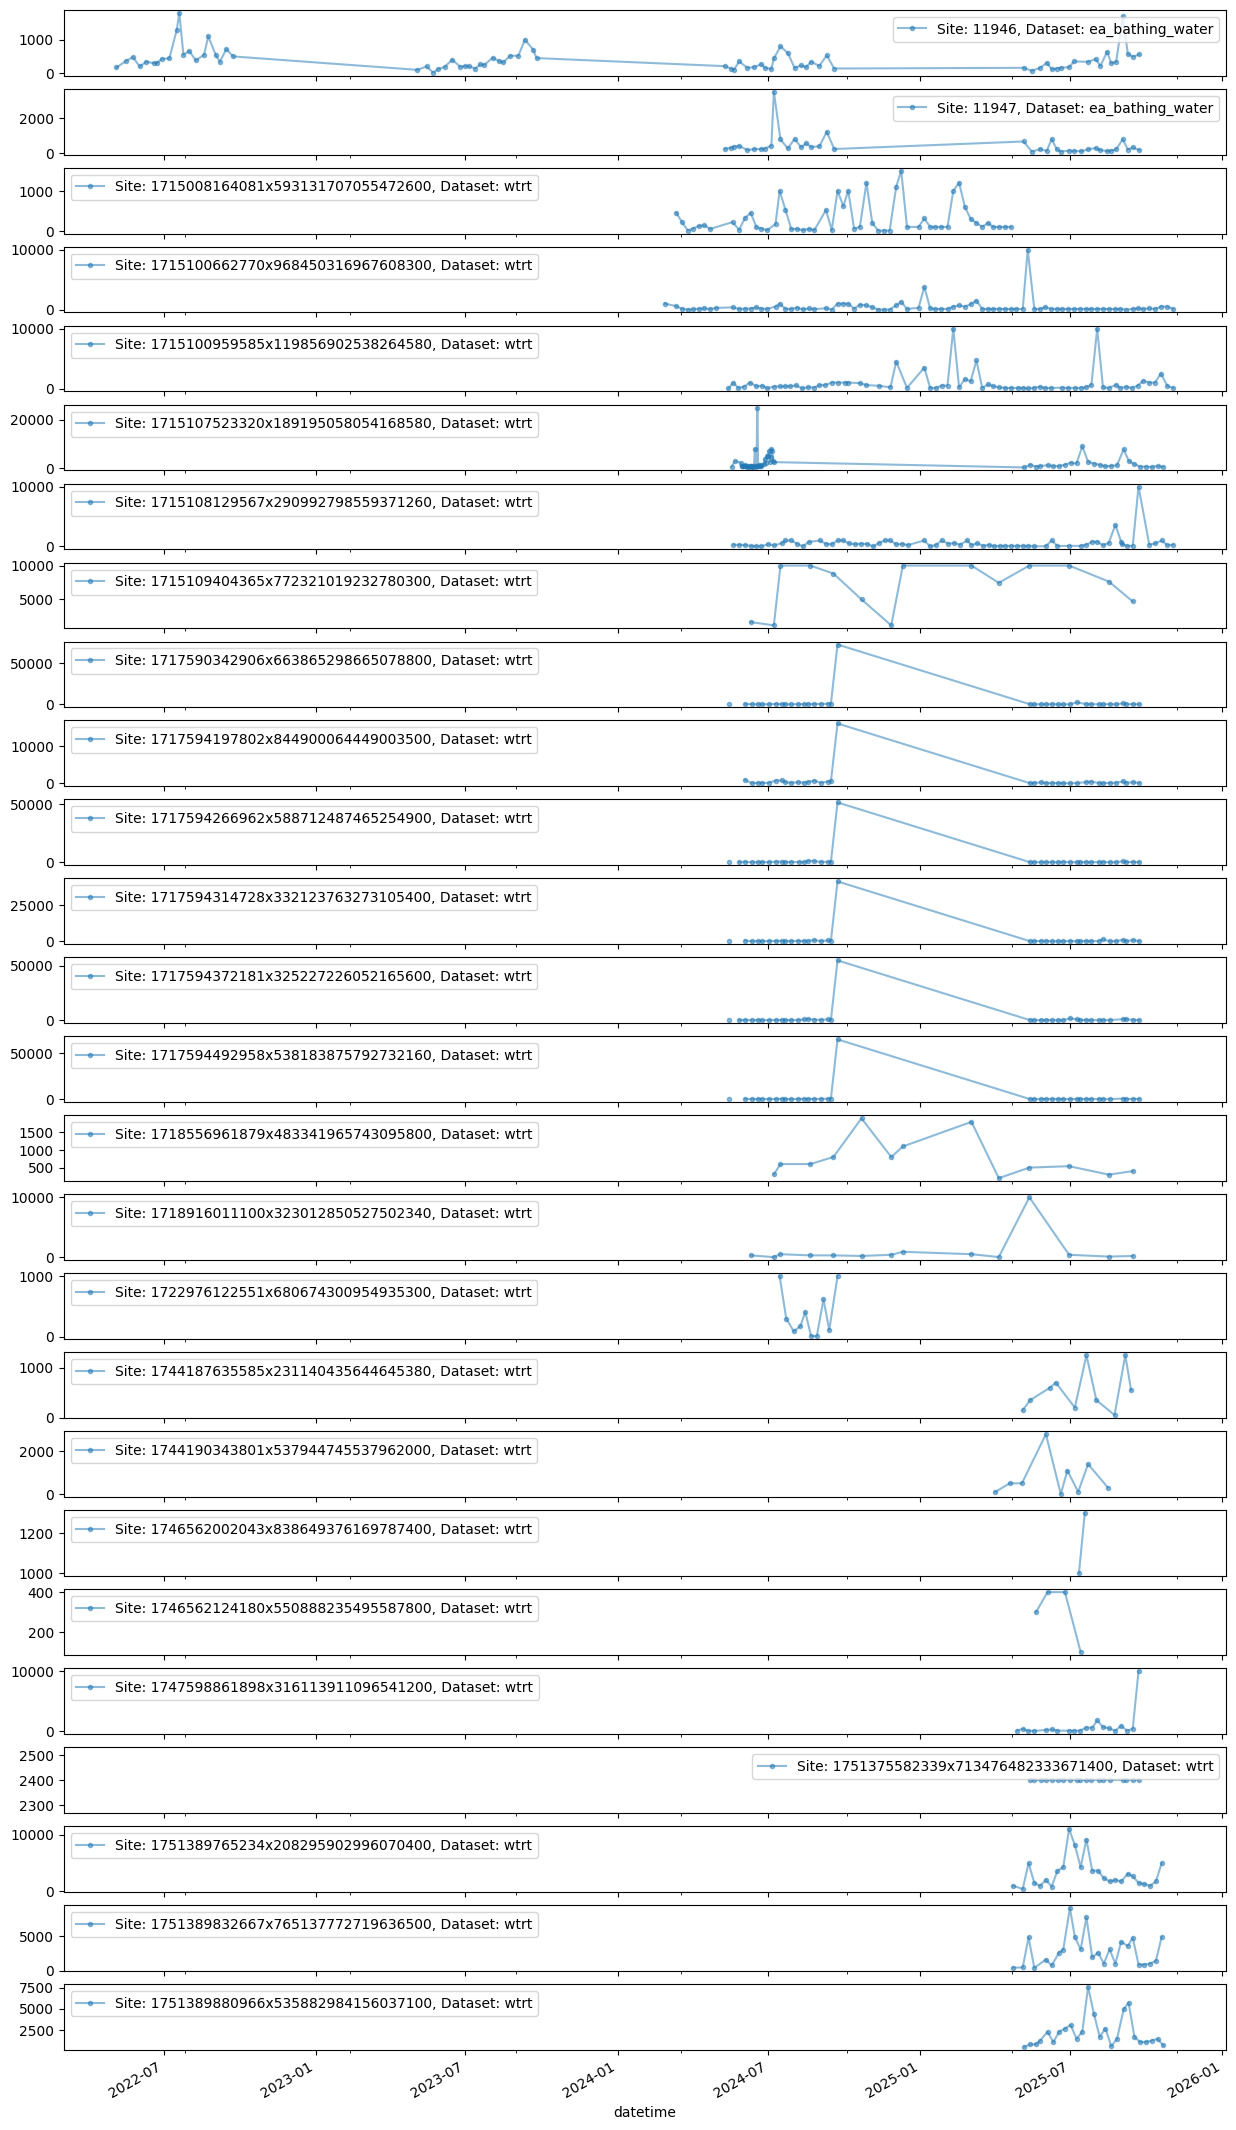

In [47]:
no_dfs = len(ecoli_timeseries_dfs)

fig, ax = plt.subplots(no_dfs, figsize=(15, 30), sharex=True)

#properly align dates, fill missing dates with NaN, deal with multiple measurements in a day
dates_complete = pd.date_range(start='2021-01-01', end='2025-11-01', freq='D')

for i, (df, key) in enumerate(zip(ecoli_timeseries_dfs.values(), ecoli_timeseries_dfs.keys())):
    df['datetime'] = df['datetime'].dt.floor('D') # Keep date only, ignore time of measurement
    df = df.groupby('datetime').first().reset_index() #in case of multiple measurements in a day, take first
    #df = df.set_index('datetime').reindex(dates_complete).reset_index().rename(columns={'index': 'datetime'})
    df.plot(x='datetime', y='escherichia coli count', ax=ax[i], alpha=0.5, label = f'Site: {key[0]}, Dataset: {key[1]}', style='.-')
    ax[i].legend()

Get datasets near wolvercote site

In [48]:
all_datasets = ['ea_bathing_water', 'edm', 'rainfall', 'fft', 'ea_water_quality', 'ea_lf_sonde', 'ea_wq_sonde', 'freshwater_watch', 'ea_flood_warnings']

target_dataset = 'ea_bathing_water' #change to desired target dataset
target_name = 'Wolvercote Mill Stream'

predictor_datasets = [ds for ds in all_datasets if ds != target_dataset]
site_names_determinands = ['ea_water_quality', 'ea_wq_sonde', 'freshwater_watch']

sites_dfs = {}

#extract all site details and convert to GeoDataFrames
for dataset_name in all_datasets:
    df = app.get_sites_for_dataset_as_pandas(dataset_name, display=False)
    df = gpd.GeoDataFrame(df)
    df['geometry.coordinates'] = gpd.points_from_xy(pd.DataFrame(df["geometry.coordinates"].to_list())[0], pd.DataFrame(df["geometry.coordinates"].to_list())[1])
    df.set_geometry('geometry.coordinates', inplace=True)
    sites_dfs[dataset_name] = df

In [49]:
#extract details about target dataset
target_location = sites_dfs[target_dataset][sites_dfs[target_dataset]["properties.name"] == target_name]["geometry.coordinates"]
target_id = sites_dfs[target_dataset][sites_dfs[target_dataset]["properties.name"] == target_name]["properties.id"].values[0]
target_ecoli = ecoli_timeseries_dfs[(target_id, target_dataset)].set_index('datetime')
df_target = pd.DataFrame(index = dates_complete)
df_target = pd.concat([df_target, target_ecoli['escherichia coli count']], axis = 1) #extract e-coli as target variable

enterococci_predictor = target_ecoli['intestinal enterococci count'] #extract enterococci as predictor variable to add to other predictors

In [50]:
# find sites near target location

max_distance = 0.075 # e.g., within 0.075 degrees (~8 km)

nearby_dfs = {}

for dataset_name in predictor_datasets:
    df = sites_dfs[dataset_name]
    df['distance_to_target'] = df['geometry.coordinates'].distance(target_location.values[0])
    nearby_sites = df[df['distance_to_target'] < max_distance]
    nearby_dfs[dataset_name] = nearby_sites

In below cell, trying to collate time series for all nearby sites. However this is difficult as the data is all in different formats:

Working:

rainfall

fft


Not working:

edm
ea_lf_sonde

ea_flood warnings


Not attempted determinand sites:

ea_water_quality

ea_wq_sonde

freshwater_watch

In [51]:
timeseries_dfs = {}

for dataset_name in predictor_datasets:
    df_sites = nearby_dfs[dataset_name]
    if dataset_name not in site_names_determinands:
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            try:
                site_name = row['properties.id']
                df_site = app.get_timeseries_for_dataset_and_site_as_pandas(site_name, dataset_name, display=False)
                df_site = df_site.rename(columns={'value': f'{dataset_name}_{site_name}'})
                df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                
                if dataset_name == 'fft':
                        df_site['datetime'] = df_site['datetime'].dt.floor('D') # Get average per day
                        df_site = df_site.groupby('datetime').mean().reset_index()

                df_site = df_site.set_index('datetime')
                timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)
            except Exception as e:
                print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")

    else: #i.e. datasets that require determinand IDs to extract timeseries
        #df_site = app.get_timeseries_for_dataset_site_determinand_as_pandas("E01612A", "ea_wq_sonde", "turbidity", display=False)
        continue


Error processing site Cassington in dataset edm: 'datetime'
Error processing site The Willows, North Hinksey Lane in dataset edm: 'datetime'
Error processing site West Way, Botley (Syphon) in dataset edm: 'datetime'
Error processing site 7500ccb3-dc3b-49fb-ac42-241fd7ab908c in dataset ea_lf_sonde: Expecting value: line 1 column 1 (char 0)
Error processing site c6558cab-e0cb-4971-94fa-89df65bec929 in dataset ea_lf_sonde: Expecting value: line 1 column 1 (char 0)
Error processing site 745d25c4-7e29-48a9-bfe7-cc14eea17751 in dataset ea_lf_sonde: Expecting value: line 1 column 1 (char 0)
Error processing site d3ed05d0-98fe-4dfb-9281-8e049743f92d in dataset ea_lf_sonde: Expecting value: line 1 column 1 (char 0)
Error processing site 5086b349-e04b-4f8e-b8f1-fa92b21078d0 in dataset ea_lf_sonde: Expecting value: line 1 column 1 (char 0)
Error processing site 8afc6e20-b0bd-4b79-bf65-345dac8cafee_1290_w1TH in dataset ea_lf_sonde: Expecting value: line 1 column 1 (char 0)
Error processing site 8a

In [52]:
#bring all time series into a common dataframe

df_predictors = pd.DataFrame(index = dates_complete)

for dataset_name, df in timeseries_dfs.items():
    df_predictors = pd.concat([df_predictors, df], axis=1)

df_predictors = pd.concat([df_predictors, enterococci_predictor], axis=1)

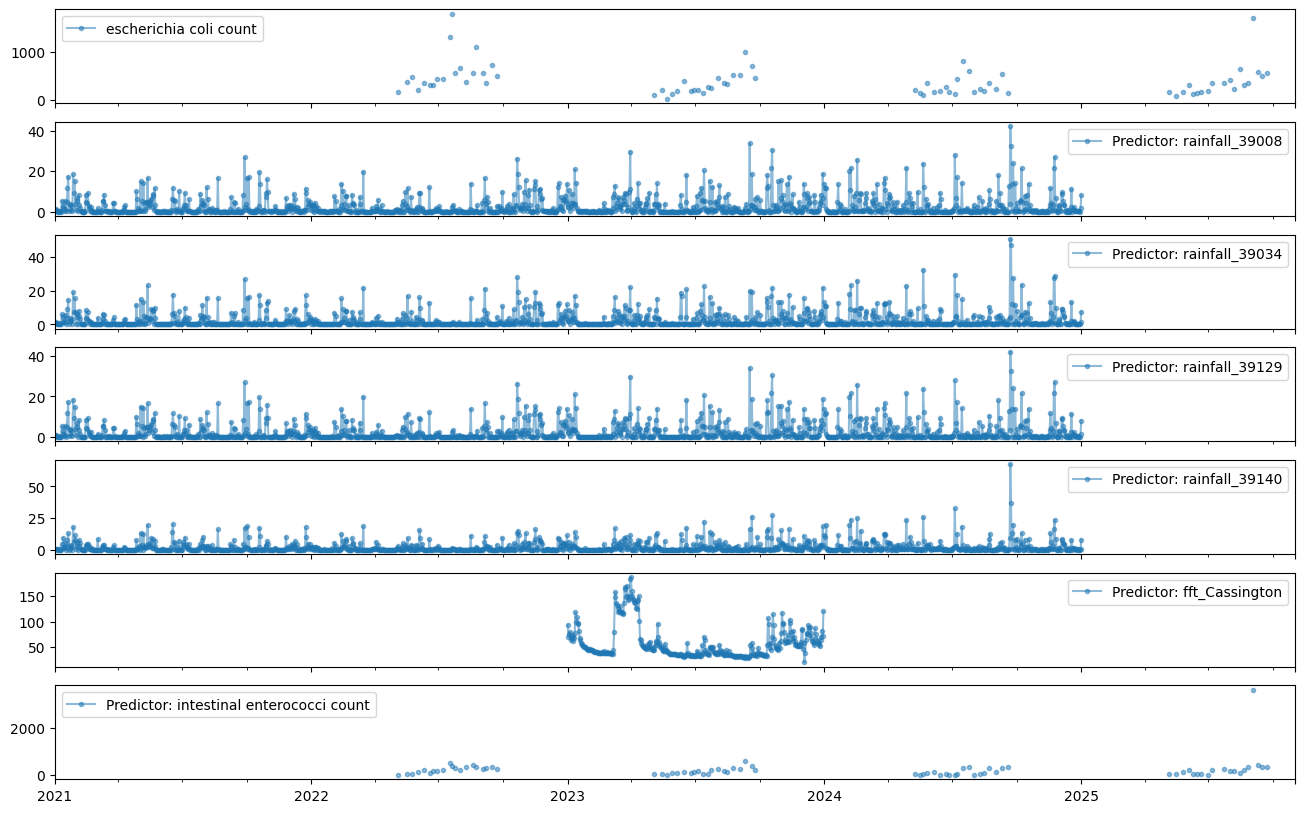

In [53]:
no_predictors = len(df_predictors.columns)
fig, ax = plt.subplots(no_predictors + 1, figsize=(16, 10), sharex = True)

df_target.plot(ax=ax[0], alpha = 0.5, label = 'Target: E. coli count', style='.-')
ax[0].legend()

for i, column in enumerate(df_predictors.columns):
    df_predictors[column].plot(ax=ax[i+1], alpha = 0.5, label = f'Predictor: {column}', style='.-')
    ax[i+1].legend()

To put into an ML algorithm, the datatime for predictors needs to match the target

In [54]:
df_target_predictors = pd.concat([df_target, df_predictors], axis=1).dropna()
df_target_predictors

,escherichia coli count,rainfall_39008,rainfall_39034,rainfall_39129,rainfall_39140,fft_Cassington,intestinal enterococci count
2023-05-04,100.0,3.688,4.445,3.677,2.204,43.434965,36.0
2023-05-15,200.0,0.015,0.005,0.016,0.043,46.681229,55.0
2023-05-23,18.0,0.000,0.000,0.000,0.000,39.871833,27.0
2023-05-29,120.0,0.000,0.000,0.000,0.000,36.133956,91.0
2023-06-06,190.0,0.000,0.002,0.000,0.007,34.561510,82.0
2023-06-15,400.0,0.000,0.000,0.000,0.000,32.101984,150.0
2023-06-25,190.0,0.001,0.000,0.001,0.001,34.652890,110.0
2023-06-30,210.0,0.697,0.434,0.695,0.618,33.077345,130.0
2023-07-05,210.0,0.183,0.284,0.178,0.280,37.464043,160.0
2023-07-13,140.0,5.326,2.775,5.378,1.047,35.629326,73.0


Some variables with short time series would need to be removed

In [55]:
df_target_predictors = pd.concat([df_target, df_predictors.drop(columns = 'fft_Cassington')], axis=1).dropna()
df_target_predictors

,escherichia coli count,rainfall_39008,rainfall_39034,rainfall_39129,rainfall_39140,intestinal enterococci count
2022-05-05,170.0,0.016,0.003,0.017,0.115,10.0
2022-05-17,370.0,2.649,3.428,2.666,2.032,55.0
2022-05-25,480.0,0.170,0.207,0.172,0.184,55.0
2022-06-02,200.0,0.001,0.000,0.001,0.000,120.0
2022-06-10,340.0,0.015,0.004,0.015,0.001,200.0
2022-06-19,300.0,0.534,0.112,0.528,0.498,110.0
2022-06-23,300.0,0.184,0.268,0.176,0.421,160.0
2022-06-29,430.0,0.593,0.074,0.600,0.031,190.0
2022-07-08,440.0,0.000,0.000,0.000,0.000,230.0
2022-07-17,1300.0,0.013,0.001,0.013,0.001,520.0


Predictors can be lagged to predict forward in time

In this case however, I'm not sure how doing a prediction would work. The target (e-coli at Wolvercote) is measured irregularly and not very often. 

The aim of the project was to be able to predict e-coli e.g. 2 days ahead, but ecoli isn't measured at daily frequency which makes this difficult

If enough other data exists at daily frequency, we could train and test the model with the available e-coli data. The same model could then be used to predict e-coli on days when it isn't measured, using the predictors that are measured.

In [56]:
df_target = df_target_predictors['escherichia coli count']

df_predictors = df_target_predictors.shift(2)

In [57]:
df_target

2022-05-05     170.0
2022-05-17     370.0
2022-05-25     480.0
2022-06-02     200.0
2022-06-10     340.0
2022-06-19     300.0
2022-06-23     300.0
2022-06-29     430.0
2022-07-08     440.0
2022-07-17    1300.0
2022-07-20    1800.0
2022-07-25     550.0
2022-08-01     660.0
2022-08-09     380.0
2022-08-19     550.0
2022-08-24    1100.0
2022-09-02     550.0
2022-09-07     340.0
2022-09-15     720.0
2022-09-23     500.0
2023-05-04     100.0
2023-05-15     200.0
2023-05-23      18.0
2023-05-29     120.0
2023-06-06     190.0
2023-06-15     400.0
2023-06-25     190.0
2023-06-30     210.0
2023-07-05     210.0
2023-07-13     140.0
2023-07-19     260.0
2023-07-24     250.0
2023-08-03     460.0
2023-08-11     360.0
2023-08-16     320.0
2023-08-24     520.0
2023-09-03     520.0
2023-09-11    1000.0
2023-09-21     700.0
2023-09-25     450.0
2024-05-10     210.0
2024-05-17     140.0
2024-05-21     110.0
2024-05-27     350.0
2024-06-06     160.0
2024-06-14     180.0
2024-06-23     270.0
2024-06-27   

In [58]:
df_predictors

,escherichia coli count,rainfall_39008,rainfall_39034,rainfall_39129,rainfall_39140,intestinal enterococci count
2022-05-05,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-17,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-25,170.0,0.016,0.003,0.017,0.115,10.0
2022-06-02,370.0,2.649,3.428,2.666,2.032,55.0
2022-06-10,480.0,0.170,0.207,0.172,0.184,55.0
2022-06-19,200.0,0.001,0.000,0.001,0.000,120.0
2022-06-23,340.0,0.015,0.004,0.015,0.001,200.0
2022-06-29,300.0,0.534,0.112,0.528,0.498,110.0
2022-07-08,300.0,0.184,0.268,0.176,0.421,160.0
2022-07-17,430.0,0.593,0.074,0.600,0.031,190.0
